# Milestone 3 - YOLOv8 fine-tuning and test evaluation

This notebook fine-tunes COCO-pretrained **YOLOv8n** on the saved Milestone 2 dataset and evaluates the best validation-selected checkpoint on the held-out test split. It produces loss curves, per-class and overall AP/mAP, precision, recall and bounding-box IoU, plus CSV reports and checkpoints.

**Run instructions:** Put this file in `milestone3/` inside the extracted repository. In local Jupyter, launch from the repository or `milestone3/`. In Colab, choose a T4 GPU, place the extracted repository in Google Drive, and set `PROJECT_DIR` below to that folder. Run cells in order. Internet is needed for package installation and the first pretrained-weight download. Training is not pre-executed: all reported numbers will come from your run.

The finalized dataset has 600 train, 200 validation and 200 test images, including augmented copies in **all three** splits. This notebook preserves that dataset. Test results therefore describe this synthetic, partly augmented benchmark, not performance on real group photographs. If your rubric requires train-only augmentation, finalize that correction in Milestone 2 **before** training; do not alter the benchmark after seeing test results.

## 1. Install and locate the project

In [1]:
 %pip install -q "ultralytics>=8.3,<9" pandas matplotlib pyyaml pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 5.3 MB/s eta 0:00:00


In [2]:
import sys
import json
import platform
import hashlib
import subprocess
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import yaml
import torch
import ultralytics
from ultralytics import YOLO
from IPython.display import display

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"

# Locate or download the repository.
if "google.colab" in sys.modules:
    ROOT = Path("/content/IE7615-Group3-Project1")

    if not ROOT.exists():
        subprocess.run(
            ["git", "clone", REPO_URL, str(ROOT)],
            check=True
        )
else:
    # Local Jupyter: run from the repository or one of its subfolders.
    ROOT = next(
        (
            folder
            for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder / "data/detection/data.yaml").is_file()
        ),
        None
    )

if ROOT is None or not (ROOT / "data/detection/data.yaml").is_file():
    raise FileNotFoundError(
        "Repository dataset not found. Check that the repository "
        "contains data/detection/data.yaml."
    )

ROOT = ROOT.resolve()
DATA = ROOT / "data/detection"

# Use a GPU when available.
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# Create a separate output directory for each run.
RUN_ID = datetime.now(timezone.utc).strftime(
    "yolov8n_%Y%m%d_%H%M%S_%f"
)
OUT = ROOT / "results/milestone3" / RUN_ID
OUT.mkdir(parents=True, exist_ok=False)

print("Project:", ROOT)
print("Dataset:", DATA)
print("Device:", DEVICE)
print("Outputs:", OUT)

if DEVICE == "cpu":
    print(
        "GPU is unavailable. In Colab, select "
        "Runtime → Change runtime type → T4 GPU."
    )

# Record package versions for reproducibility.
versions = {
    "python": platform.python_version(),
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}

(OUT / "environment.json").write_text(
    json.dumps(versions, indent=2)
)

print("Environment:", versions)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Project: /content/IE7615-Group3-Project1
Dataset: /content/IE7615-Group3-Project1/data/detection
Device: cpu
Outputs: /content/IE7615-Group3-Project1/results/milestone3/yolov8n_20261009_021724_038755
GPU is unavailable. In Colab, select Runtime → Change runtime type → T4 GPU.
Environment: {'python': '3.13.16', 'ultralytics': '8.4.174', 'torch': '2.11.0+cpu', 'numpy': '2.1.3', 'pandas': '2.2.3'}


## 2. Audit saved labels and create a runtime dataset YAML
No data is regenerated or moved. Absolute paths avoid Ultralytics resolving the original relative paths against a different dataset directory. The audit checks image/label pairs, classes, normalized coordinates, positive box sizes and box boundaries. A manifest records input hashes for reproducibility. This checks the saved detection files; source-face leakage verification remains the responsibility of Milestone 2.

In [3]:
original_config = yaml.safe_load((DATA / "data.yaml").read_text())
raw_names = original_config["names"]
NAMES = ({int(k): str(v) for k, v in raw_names.items()} if isinstance(raw_names, dict)
         else dict(enumerate(raw_names)))
assert sorted(NAMES) == list(range(len(NAMES))), "Classes must have contiguous IDs from zero."
NC = len(NAMES)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}
SPLIT_IMAGES, counts, manifest = {}, [], []

def read_labels(path):
    lines = path.read_text().strip().splitlines()
    if not lines:
        return np.empty((0, 5), dtype=float)
    values = np.array([[float(v) for v in line.split()] for line in lines], dtype=float)
    assert values.ndim == 2 and values.shape[1] == 5, f"Malformed labels: {path}"
    assert np.isfinite(values).all(), f"Nonfinite label: {path}"
    assert np.all(values[:, 0] == values[:, 0].astype(int)), f"Noninteger class: {path}"
    assert np.all((values[:, 0] >= 0) & (values[:, 0] < NC)), f"Unknown class: {path}"
    xy, wh = values[:, 1:3], values[:, 3:5]
    assert np.all((values[:, 1:] >= 0) & (values[:, 1:] <= 1)), f"Not normalized: {path}"
    assert np.all(wh > 0), f"Zero-size box: {path}"
    assert np.all(xy - wh / 2 >= -1e-5) and np.all(xy + wh / 2 <= 1 + 1e-5), f"Out-of-image box: {path}"
    return values

for split in ("train", "val", "test"):
    images = sorted(p for p in (DATA / "images" / split).iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
    assert images, f"Empty split: {split}"
    stems = [p.stem for p in images]
    assert len(stems) == len(set(stems)), f"Duplicate image stems: {split}"
    labels = {p.stem: p for p in (DATA / "labels" / split).glob("*.txt")}
    assert set(stems) == set(labels), f"Unpaired images/labels: {split}"
    class_counts = np.zeros(NC, dtype=int)
    for p in images:
        a = read_labels(labels[p.stem])
        class_counts += np.bincount(a[:, 0].astype(int), minlength=NC)
        manifest.append({"split": split, "image": str(p.relative_to(ROOT)),
                         "image_sha256": hashlib.sha256(p.read_bytes()).hexdigest(),
                         "label_sha256": hashlib.sha256(labels[p.stem].read_bytes()).hexdigest()})
    assert np.all(class_counts > 0), f"Missing identity in {split}"
    SPLIT_IMAGES[split] = images
    counts.append({"split": split, "images": len(images),
                   "augmented_images": sum("_aug_" in p.stem for p in images),
                   "faces": int(class_counts.sum()),
                   **{NAMES[i]: int(class_counts[i]) for i in NAMES}})
counts = pd.DataFrame(counts)
display(counts)
counts.to_csv(OUT / "dataset_counts.csv", index=False)
manifest = pd.DataFrame(manifest)
assert manifest.groupby("image_sha256")["split"].nunique().max() == 1, "Exact image overlap across splits."
manifest.to_csv(OUT / "dataset_manifest.csv", index=False)
DATA_YAML = OUT / "dataset_absolute.yaml"
DATA_YAML.write_text(yaml.safe_dump({"path": str(DATA.resolve()),
    "train": str((DATA / "images/train").resolve()),
    "val": str((DATA / "images/val").resolve()),
    "test": str((DATA / "images/test").resolve()), "names": NAMES}, sort_keys=False))

,split,images,augmented_images,faces,id_2336,id_2970,id_4422,id_7007
0,train,600,300,1656,416,411,414,415
1,val,200,100,564,131,145,140,148
2,test,200,100,543,142,142,129,130


307

## 3. Fine-tune YOLOv8 (Task 1)
Use up to **150 epochs**, with early stopping after **30 epochs** without validation-fitness improvement. All layers are fine-tuned. The checkpoint `best.pt` is selected using validation fitness, never test performance. A fresh run directory prevents accidental overwriting.

Extra geometric/color augmentation is disabled here because the saved dataset already includes augmentation. Set batch size to 8 or 4 if GPU memory is insufficient. Set thresholds **before** testing: confidence 0.25, class-aware NMS IoU 0.70, and TP matching IoU 0.50. The NMS threshold is different from the evaluation matching threshold.

150 epochs is a training budget, not proof of convergence. Review the next section before running the test evaluation. If validation performance is still improving, revise the training budget using validation results only.

In [4]:
EPOCHS = 150
PATIENCE = 30
BATCH = 16
IMGSZ = 640
SEED = 42
REPORT_CONF = 0.25
MATCH_IOU = 0.50
NMS_IOU = 0.70
MAX_DET = 100
settings = dict(checkpoint="yolov8n.pt", epochs=EPOCHS, patience=PATIENCE,
    batch=BATCH, imgsz=IMGSZ, seed=SEED, report_conf=REPORT_CONF,
    match_iou=MATCH_IOU, nms_iou=NMS_IOU, max_det=MAX_DET)
(OUT / "protocol.json").write_text(json.dumps(settings, indent=2))
model = YOLO("yolov8n.pt")
model.train(
    data=str(DATA_YAML), epochs=EPOCHS, patience=PATIENCE,
    imgsz=IMGSZ, batch=BATCH, device=DEVICE, workers=0,
    optimizer="AdamW", lr0=0.001, lrf=0.01, weight_decay=0.0005,
    cos_lr=True, warmup_epochs=3, seed=SEED, deterministic=True,
    mosaic=0.0, mixup=0.0, copy_paste=0.0, degrees=0.0,
    translate=0.0, scale=0.0, shear=0.0, perspective=0.0,
    fliplr=0.0, flipud=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    close_mosaic=0, val=True, plots=True, save=True, cache=False,
    project=str(OUT), name="train", exist_ok=False,
)
TRAIN_DIR = Path(model.trainer.save_dir)
BEST = TRAIN_DIR / "weights/best.pt"
assert BEST.is_file(), "Training did not produce best.pt."
print("Best validation-selected checkpoint:", BEST)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/IE7615-Group3-Project1/results/milestone3/yolov8n_20261009_021724_038755/dataset_absolute.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, 

## 4. Capture losses and assess convergence

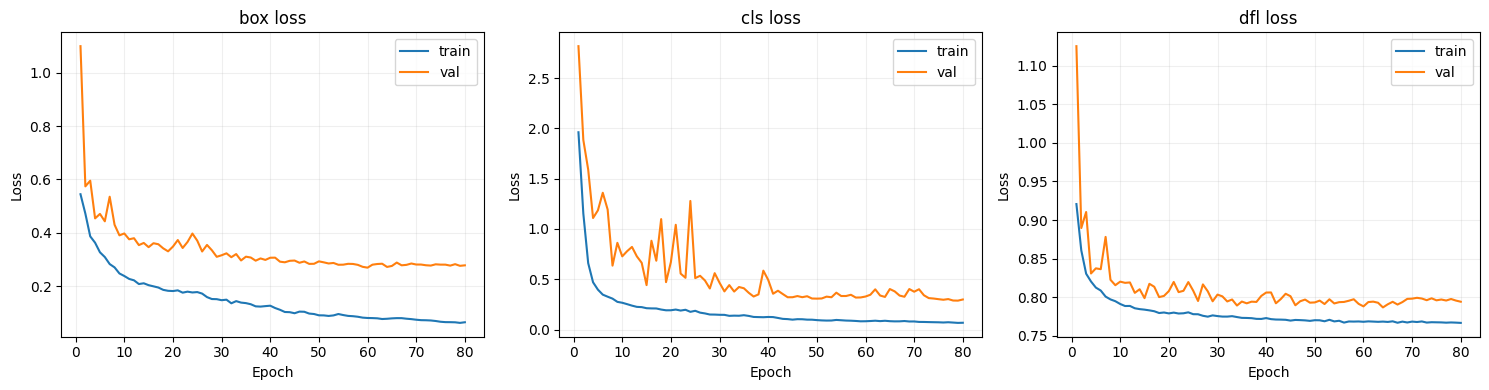

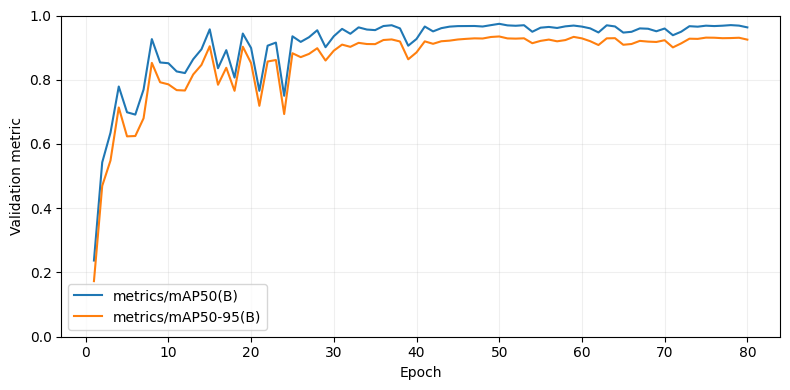

Epochs completed: 80; highest validation mAP50-95: 0.9347 at epoch 50
Last 10 vs preceding 10 epoch mean validation mAP50-95 change: +0.0059
Inspect loss flattening, validation mAP stability, and any train/val divergence; early stopping alone is not proof of convergence.


In [5]:
history = pd.read_csv(TRAIN_DIR / "results.csv")
history.columns = history.columns.str.strip()
history.to_csv(OUT / "training_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, term in zip(axes, ["box_loss", "cls_loss", "dfl_loss"]):
    for split in ["train", "val"]:
        ax.plot(history["epoch"], history[f"{split}/{term}"], label=split)
    ax.set(title=term.replace("_", " "), xlabel="Epoch", ylabel="Loss")
    ax.grid(alpha=0.2); ax.legend()
fig.tight_layout(); fig.savefig(OUT / "loss_curves.png", dpi=180); plt.show()
fig, ax = plt.subplots(figsize=(8, 4))
for key in ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
    ax.plot(history["epoch"], history[key], label=key)
ax.set(xlabel="Epoch", ylabel="Validation metric", ylim=(0, 1))
ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(OUT / "validation_map_curves.png", dpi=180); plt.show()
metric = "metrics/mAP50-95(B)"
peak = history.loc[history[metric].idxmax()]
print(f"Epochs completed: {len(history)}; highest validation mAP50-95: {peak[metric]:.4f} at epoch {int(peak['epoch'])}")
if len(history) >= 20:
    recent = history[metric].tail(10).mean()
    previous = history[metric].iloc[-20:-10].mean()
    print(f"Last 10 vs preceding 10 epoch mean validation mAP50-95 change: {recent - previous:+.4f}")
    if recent - previous > 0.01:
        print("Validation mAP is still improving noticeably. Review whether a longer run is needed BEFORE test evaluation.")
print("Inspect loss flattening, validation mAP stability, and any train/val divergence; early stopping alone is not proof of convergence.")

## 5. Held-out test AP/mAP (Task 2)
Run this only after the training protocol and checkpoint are finalized. AP integrates the precision–recall curve; use a low prediction confidence floor (0.001) to retain the curve, not the fixed reporting threshold. Per-class values are **AP**; their average across the four identities is **mAP**. The test split is not used for checkpoint selection or threshold tuning.

Ultralytics also returns precision and recall at its internally selected curve operating point. Those are saved separately for reference. The main combined report below uses predeclared confidence 0.25 instead, making its precision/recall and matched IoU directly interpretable together.

In [6]:
best_model = YOLO(str(BEST))
test_metrics = best_model.val(
    data=str(DATA_YAML), split="test", imgsz=IMGSZ, batch=BATCH,
    device=DEVICE, workers=0, conf=0.001, iou=NMS_IOU,
    max_det=MAX_DET, augment=False, plots=True,
    project=str(OUT), name="test_standard", exist_ok=False,
)
# Map metric positions explicitly to class IDs; never assume missing classes disappear safely.
ap_by_class = {i: {"AP50": 0.0, "AP50_95": 0.0,
                   "P_ultralytics_curve": 0.0, "R_ultralytics_curve": 0.0} for i in NAMES}
for pos, class_id in enumerate(test_metrics.box.ap_class_index):
    p, r, ap50, ap = test_metrics.box.class_result(pos)
    ap_by_class[int(class_id)] = dict(AP50=float(ap50), AP50_95=float(ap),
        P_ultralytics_curve=float(p), R_ultralytics_curve=float(r))
ap_table = pd.DataFrame([dict(class_id=i, identity=NAMES[i], **ap_by_class[i]) for i in NAMES])
ap_table.to_csv(OUT / "test_standard_per_class.csv", index=False)
(OUT / "test_standard_overall.json").write_text(json.dumps(
    {k: float(v) for k, v in test_metrics.results_dict.items()}, indent=2))
display(ap_table.round(4))

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.1±0.0 ms, read: 19.0±17.2 MB/s, size: 64.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/IE7615-Group3-Project1/data/detection/labels/test... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 446.7it/s 0.4s
val: New cache created: /content/IE7615-Group3-Project1/data/detection/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.4s/it 30.7s
                   all        200        543      0.976      0.959      0.983      0.941
               id_2336        142        142      0.968      0.965      0.988      0.931
               id_2970        142        142      0.963     

,class_id,identity,AP50,AP50_95,P_ultralytics_curve,R_ultralytics_curve
0,0,id_2336,0.9876,0.9314,0.9680,0.9648
1,1,id_2970,0.9788,0.9502,0.9632,0.9718
2,2,id_4422,0.9898,0.9547,0.9801,0.9690
3,3,id_7007,0.9742,0.9270,0.9918,0.9323


## 6. Fixed-threshold precision, recall and bounding-box IoU
Predictions with confidence ≥0.25 are matched in descending confidence order to the highest-IoU **unmatched ground-truth box of the same identity**, requiring IoU ≥0.50. Each prediction and ground-truth box may be matched only once. Wrong identities and duplicate predictions count as false positives; unmatched ground truth counts as false negatives.

- **Precision:** TP / (TP + FP); **recall:** TP / (TP + FN).
- **Mean matched IoU:** mean box intersection-over-union among true-positive matches. This is conditional on successful detection; it is undefined (NaN) if there are no matches.
- **GT-normalized IoU:** sum of matched IoUs / number of ground-truth faces, counting misses as zero. This supplemental measure exposes missed faces that matched-only IoU excludes; it does not penalize extra predictions, so read it alongside precision.
- Overall precision/recall pool counts (**micro**); overall matched IoU pools matched boxes. mAP remains a **macro** average across identities. Undefined precision with no predictions is reported as 0 by convention.

These box IoUs are custom localization summaries, not segmentation IoU or mAP. The matching protocol can differ from Ultralytics' internal AP matching, so fixed-threshold P/R need not equal its curve summaries.

In [7]:
def box_iou_one(box, targets):
    targets = np.asarray(targets, dtype=float).reshape(-1, 4)
    lo = np.maximum(box[:2], targets[:, :2])
    hi = np.minimum(box[2:], targets[:, 2:])
    inter = np.maximum(hi - lo, 0).prod(axis=1)
    area1 = np.maximum(box[2:] - box[:2], 0).prod()
    area2 = np.maximum(targets[:, 2:] - targets[:, :2], 0).prod(axis=1)
    return inter / np.maximum(area1 + area2 - inter, 1e-12)

def match_image(gt_boxes, gt_classes, pred_boxes, pred_classes, scores):
    used = set()
    matches = []
    for pi in np.argsort(-np.asarray(scores), kind="stable"):
        candidates = [gi for gi, cls in enumerate(gt_classes)
                      if cls == pred_classes[pi] and gi not in used]
        if not candidates:
            continue
        ious = box_iou_one(pred_boxes[pi], gt_boxes[candidates])
        idx = int(np.argmax(ious))
        if ious[idx] >= MATCH_IOU:
            gi = candidates[idx]
            used.add(gi)
            matches.append((int(pi), int(gi), float(ious[idx])))
    return matches

# Small checks cover duplicate detections, wrong identities, and empty predictions.
b = np.array([[0., 0., 10., 10.]])
assert np.isclose(box_iou_one(b[0], b)[0], 1.0)
assert len(match_image(b, [0], np.repeat(b, 2, axis=0), [0, 0], [.9, .8])) == 1
assert len(match_image(b, [0], b, [1], [.9])) == 0
assert len(match_image(b, [0], np.empty((0, 4)), [], [])) == 0
assert np.isclose(box_iou_one(np.array([5., 0., 15., 10.]), b)[0], 1/3)
print("IoU and one-to-one matching checks passed.")

IoU and one-to-one matching checks passed.


In [8]:
stats = {i: {"GT": 0, "TP": 0, "FP": 0, "FN": 0, "ious": []} for i in NAMES}
match_rows = []
# Streaming prediction keeps only one batch of results in memory.
results = best_model.predict(
    source=[str(p) for p in SPLIT_IMAGES["test"]], stream=True,
    imgsz=IMGSZ, batch=BATCH, device=DEVICE, conf=REPORT_CONF,
    iou=NMS_IOU, max_det=MAX_DET, agnostic_nms=False,
    augment=False, verbose=False, save=False,
)
seen = set()
for result in results:
    image_path = Path(result.path)
    seen.add(image_path.stem)
    labels = read_labels(DATA / "labels/test" / (image_path.stem + ".txt"))
    h, w = result.orig_shape
    centers = labels[:, 1:3] * [w, h]
    sizes = labels[:, 3:5] * [w, h]
    gt_boxes = np.concatenate([centers - sizes / 2, centers + sizes / 2], axis=1)
    gt_classes = labels[:, 0].astype(int)
    pred_boxes = result.boxes.xyxy.cpu().numpy()
    pred_classes = result.boxes.cls.cpu().numpy().astype(int)
    scores = result.boxes.conf.cpu().numpy()
    matches = match_image(gt_boxes, gt_classes, pred_boxes, pred_classes, scores)
    for i in NAMES:
        ious = [v for pi, gi, v in matches if gt_classes[gi] == i]
        ngt, npred, ntp = int((gt_classes == i).sum()), int((pred_classes == i).sum()), len(ious)
        stats[i]["GT"] += ngt; stats[i]["TP"] += ntp
        stats[i]["FP"] += npred - ntp; stats[i]["FN"] += ngt - ntp
        stats[i]["ious"].extend(ious)
    for pi, gi, value in matches:
        match_rows.append(dict(image=image_path.name, class_id=int(gt_classes[gi]),
            prediction_index=pi, ground_truth_index=gi, confidence=float(scores[pi]), IoU=value))
assert seen == {p.stem for p in SPLIT_IMAGES["test"]}, "Some test images were not evaluated."
pd.DataFrame(match_rows, columns=["image", "class_id", "prediction_index", "ground_truth_index", "confidence", "IoU"]).to_csv(
    OUT / "test_matched_boxes.csv", index=False)

def summarize(s):
    return {k: s[k] for k in ["GT", "TP", "FP", "FN"]} | {
        "Precision_conf025": s["TP"] / max(s["TP"] + s["FP"], 1),
        "Recall_conf025": s["TP"] / max(s["GT"], 1),
        "Mean_matched_IoU": float(np.mean(s["ious"])) if s["ious"] else np.nan,
        "GT_normalized_IoU": sum(s["ious"]) / max(s["GT"], 1)}
rows = []
for i in NAMES:
    rows.append(dict(identity=NAMES[i], AP50_or_mAP50=ap_by_class[i]["AP50"],
        AP50_95_or_mAP50_95=ap_by_class[i]["AP50_95"], **summarize(stats[i])))
pooled = {k: sum(stats[i][k] for i in NAMES) for k in ["GT", "TP", "FP", "FN"]}
pooled["ious"] = [v for i in NAMES for v in stats[i]["ious"]]
rows.append(dict(identity="OVERALL", AP50_or_mAP50=np.mean([ap_by_class[i]["AP50"] for i in NAMES]),
    AP50_95_or_mAP50_95=np.mean([ap_by_class[i]["AP50_95"] for i in NAMES]), **summarize(pooled)))
report = pd.DataFrame(rows)
# Keep column names accurate if the predeclared reporting confidence was edited.
report.rename(columns={"Precision_conf025": f"Precision_conf{REPORT_CONF:g}",
                       "Recall_conf025": f"Recall_conf{REPORT_CONF:g}"}, inplace=True)
report.to_csv(OUT / "test_detection_metrics.csv", index=False)
display(report.round(4))
print("Metrics are on a 0–1 scale. OVERALL AP columns are mAP; P/R are pooled micro averages.")

,identity,AP50_or_mAP50,AP50_95_or_mAP50_95,GT,TP,FP,FN,Precision_conf0.25,Recall_conf0.25,Mean_matched_IoU,GT_normalized_IoU
0,id_2336,0.9876,0.9314,142,137,6,5,0.9580,0.9648,0.9593,0.9255
1,id_2970,0.9788,0.9502,142,139,7,3,0.9521,0.9789,0.9682,0.9477
2,id_4422,0.9898,0.9547,129,123,10,6,0.9248,0.9535,0.9685,0.9235
3,id_7007,0.9742,0.9270,130,121,8,9,0.9380,0.9308,0.9589,0.8925
4,OVERALL,0.9826,0.9408,543,520,31,23,0.9437,0.9576,0.9638,0.9230


Metrics are on a 0–1 scale. OVERALL AP columns are mAP; P/R are pooled micro averages.


## 7. Compare identities and save a concise run report

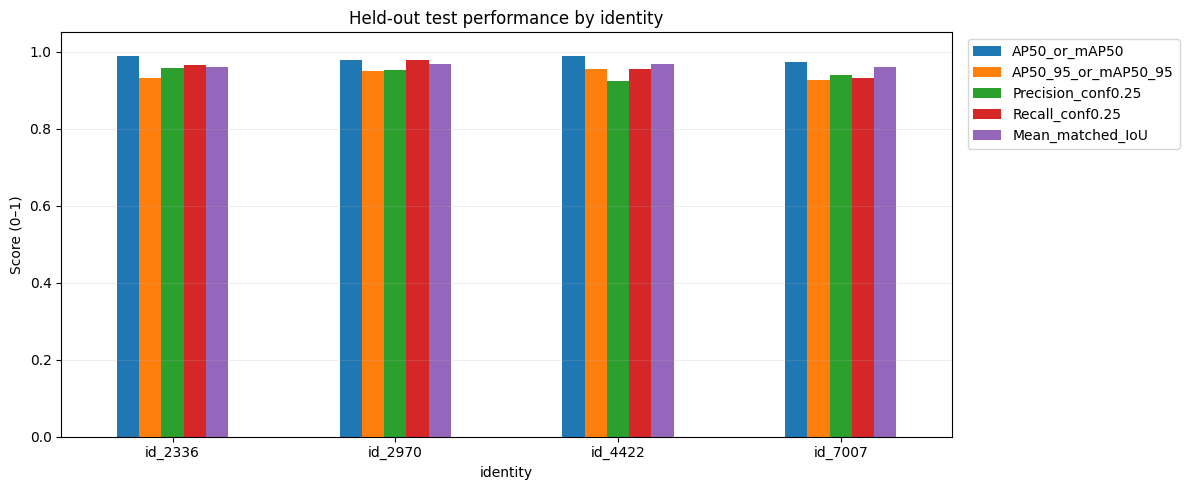

Milestone 3 run: yolov8n_20261009_021724_038755
Checkpoint: /content/IE7615-Group3-Project1/results/milestone3/yolov8n_20261009_021724_038755/train/weights/best.pt
Completed epochs: 80
Highest validation mAP50-95 epoch: 50
Highest validation mAP50-95: 0.9347
Test images: 200
Fixed report confidence: 0.25; matching IoU: 0.5; NMS IoU: 0.7
The best checkpoint was selected by validation fitness, not the test split.
Overall mAP averages identities; precision/recall pool counts; matched IoU pools true positives.
Mean matched IoU excludes misses; GT-normalized IoU counts misses as zero.
The saved test split includes original and augmented synthetic images.
Training convergence must be assessed from the exported loss and validation curves.

identity  AP50_or_mAP50  AP50_95_or_mAP50_95  GT  TP  FP  FN  Precision_conf0.25  Recall_conf0.25  Mean_matched_IoU  GT_normalized_IoU
 id_2336         0.9876               0.9314 142 137   6   5              0.9580           0.9648            0.9593       

In [9]:
plot_columns = ["AP50_or_mAP50", "AP50_95_or_mAP50_95", f"Precision_conf{REPORT_CONF:g}",
                f"Recall_conf{REPORT_CONF:g}", "Mean_matched_IoU"]
ax = report[report.identity != "OVERALL"].set_index("identity")[plot_columns].plot.bar(figsize=(12, 5), rot=0)
ax.set(ylabel="Score (0–1)", ylim=(0, 1.05), title="Held-out test performance by identity")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1)); ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.savefig(OUT / "test_metrics_by_identity.png", dpi=180); plt.show()

summary = f"""Milestone 3 run: {RUN_ID}
Checkpoint: {BEST}
Completed epochs: {len(history)}
Highest validation mAP50-95 epoch: {int(peak['epoch'])}
Highest validation mAP50-95: {peak[metric]:.4f}
Test images: {len(SPLIT_IMAGES['test'])}
Fixed report confidence: {REPORT_CONF}; matching IoU: {MATCH_IOU}; NMS IoU: {NMS_IOU}
The best checkpoint was selected by validation fitness, not the test split.
Overall mAP averages identities; precision/recall pool counts; matched IoU pools true positives.
Mean matched IoU excludes misses; GT-normalized IoU counts misses as zero.
The saved test split includes original and augmented synthetic images.
Training convergence must be assessed from the exported loss and validation curves.

{report.round(4).to_string(index=False)}
"""
(OUT / "run_summary.txt").write_text(summary)
print(summary)
print("All outputs saved under:", OUT)

## Deliverables and interpretation

| Output | Purpose |
|---|---|
| `train/weights/best.pt`, `last.pt` | Best validation checkpoint and last training checkpoint |
| `training_history.csv`, `loss_curves.png` | Training/validation box, classification and DFL losses |
| `validation_map_curves.png` | Validation AP trends for assessing convergence |
| `test_detection_metrics.csv` | Main report: per-identity and overall AP/mAP, P/R, IoU and counts |
| `test_standard_per_class.csv` | Ultralytics AP and internal curve P/R for reference |
| `test_standard/` | Ultralytics test plots, including PR/confusion-matrix plots when available |
| `test_matched_boxes.csv` | Auditable true-positive IoU matches |
| `test_metrics_by_identity.png`, `run_summary.txt` | Comparison figure and numerical summary |
| `environment.json`, `protocol.json`, `dataset_manifest.csv` | Package versions, settings and dataset fingerprints |

**For the written assignment:** State whether validation loss/mAP stabilizes and whether the training/validation gap widens. Compare the strongest and weakest identities using AP, recall and support counts. High matched IoU with low recall means the correctly found faces are well localized but many faces are missed. Do not claim convergence or any numerical result before running this notebook. The small number of unique source faces and shared source content among scenes within a split limit independence and generalization.

**References:** [Ultralytics training](https://docs.ultralytics.com/modes/train/), [validation](https://docs.ultralytics.com/modes/val/), [metrics API](https://docs.ultralytics.com/reference/utils/metrics/), [YOLOv8](https://docs.ultralytics.com/models/yolov8/). The installed package version is recorded on every run.